In [1]:
# ============================================================================
# CELDA 1: CONEXIÓN A GOOGLE DRIVE
# ============================================================================
from google.colab import drive
import os

# Montar Google Drive en el entorno de Colab
drive.mount('/content/drive')

# Definimos la ruta base de tu proyecto en Google Drive
BASE_PATH = '/content/drive/MyDrive/twitter_project'

# Verificación de seguridad para confirmar que la ruta es correcta
if os.path.exists(BASE_PATH):
    print(f"✅ Conectado con éxito a Drive. Carpeta del proyecto encontrada en: {BASE_PATH}")
else:
    print(f"⚠️ Alerta: No se encontró la carpeta '{BASE_PATH}'.")
    print("Por favor, verifica que el nombre de la carpeta en tu Drive sea exactamente 'twitter_project'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Conectado con éxito a Drive. Carpeta del proyecto encontrada en: /content/drive/MyDrive/twitter_project


In [2]:
# ============================================================================
# CELDA 2: CARGA DE DATOS DE PRUEBA Y LIMPIEZA DE BOOLEANOS (CORREGIDA)
# ============================================================================
import pandas as pd
import numpy as np

print("🔄 Cargando datos de prueba desde los archivos CSV en Drive...")

ruta_X_test = f"{BASE_PATH}/data/processed/X_test.csv"
ruta_y_test = f"{BASE_PATH}/data/processed/y_test.csv"

try:
    # 1. Leer los archivos como DataFrames para poder mapear los tipos de datos
    df_X = pd.read_csv(ruta_X_test)
    df_y = pd.read_csv(ruta_y_test)

    print("🧹 Detectando y convirtiendo posibles textos booleanos ('True'/'False') a números...")

    # 2. Convertir cualquier columna que tenga strings 'True' o 'False' a 1 y 0 numéricos
    for col in df_X.columns:
        # Reemplazar si vienen como strings con texto
        df_X[col] = df_X[col].replace({'True': 1, 'False': 0, 'True ': 1, 'False ': 0})
        # Forzar a que toda la columna sea float/int por seguridad
        df_X[col] = pd.to_numeric(df_X[col], errors='coerce').fillna(0)

    # 3. Transformar ahora sí a los arrays de NumPy que espera el pipeline
    X_test = df_X.values
    y_test = df_y.values.ravel()

    # Asegurar que y_test también sea numérico si es necesario
    if y_test.dtype == 'object':
        y_test = np.where((y_test == 'Bot') | (y_test == 'True') | (y_test == 1), 1, 0)

    print("✅ ¡Variables X_test e y_test preparadas y limpias de texto!")
    print(f"📊 Dimensiones finales de X_test: {X_test.shape}")
    print(f"📊 Dimensiones finales de y_test: {y_test.shape}")

except FileNotFoundError:
    print("❌ Error Crítico: No se encontraron los archivos CSV en la ruta esperada.")

🔄 Cargando datos de prueba desde los archivos CSV en Drive...
🧹 Detectando y convirtiendo posibles textos booleanos ('True'/'False') a números...
✅ ¡Variables X_test e y_test preparadas y limpias de texto!
📊 Dimensiones finales de X_test: (1538, 5)
📊 Dimensiones finales de y_test: (1538,)


In [3]:
# ============================================================================
# CELDA 3: LIBRERÍAS DE EVALUACIÓN Y CONFIGURACIÓN
# ============================================================================
import joblib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings('ignore')
print("✅ Librerías de evaluación importadas y listas.")

✅ Librerías de evaluación importadas y listas.


In [4]:
# ============================================================================
# CELDA 4: CARGA DEL PIPELINE DE PRODUCCIÓN
# ============================================================================
print("🔄 Cargando el pipeline final optimizado por Optuna desde Drive...")

ruta_pipeline = f"{BASE_PATH}/outputs/models/best_pipeline_model.pkl"

try:
    pipeline = joblib.load(ruta_pipeline)
    print("✅ Pipeline final cargado con éxito. ¡Listo para evaluar!")
except FileNotFoundError:
    print(f"❌ Error Crítico: No se encontró el archivo del modelo en: {ruta_pipeline}")

# Definimos las etiquetas de las clases para los reportes
class_names = ['Real Account', 'Bot']

🔄 Cargando el pipeline final optimizado por Optuna desde Drive...
✅ Pipeline final cargado con éxito. ¡Listo para evaluar!


In [5]:
# ============================================================================
# CELDA 5: PREDICCIONES EN EL CONJUNTO DE PRUEBA
# ============================================================================
print("🔮 Generando predicciones en los datos de Test...")

# Usamos el pipeline completo (aplica el Scaler y luego predice con LightGBM automáticamente)
y_pred = pipeline.predict(X_test)

# Intentamos extraer las probabilidades para calcular la métrica ROC-AUC
if hasattr(pipeline, "predict_proba"):
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
else:
    y_proba = None
    roc_auc = np.nan

print(f"✅ Predicciones completadas. Total muestras evaluadas: {len(y_pred)}")

🔮 Generando predicciones en los datos de Test...
✅ Predicciones completadas. Total muestras evaluadas: 1538


In [6]:
# ============================================================================
# CELDA 6: REPORTE DE CLASIFICACIÓN (Métricas por clase)
# ============================================================================
print("📊 REPORTE DE CLASIFICACIÓN FINAL:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=class_names))
print("-" * 60)

📊 REPORTE DE CLASIFICACIÓN FINAL:
------------------------------------------------------------
              precision    recall  f1-score   support

Real Account       0.99      0.99      0.99      1008
         Bot       0.98      0.97      0.97       530

    accuracy                           0.98      1538
   macro avg       0.98      0.98      0.98      1538
weighted avg       0.98      0.98      0.98      1538

------------------------------------------------------------


In [7]:
# ============================================================================
# CELDA 7: EXPORTACIÓN DE MÉTRICAS GENERALES A CSV
# ============================================================================
# Estructuramos los resultados globales del LightGBM ganador
metrics = {
    'Modelo': 'LightGBM (Optimizado por Optuna)',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc
}

# Lo convertimos a un DataFrame y redondeamos a 4 decimales
resultados_df = pd.DataFrame([metrics]).round(4)

# Aseguramos que exista la carpeta de destino en Drive
os.makedirs(f'{BASE_PATH}/results/metrics', exist_ok=True)

# Ruta del CSV
ruta_csv = f'{BASE_PATH}/results/metrics/resultado_modelo_final.csv'
resultados_df.to_csv(ruta_csv, index=False)

print("📝 Resumen de rendimiento global:")
print(resultados_df.to_string(index=False))
print(f"\n✅ Archivo guardado con éxito en:\n👉 {ruta_csv}")

📝 Resumen de rendimiento global:
                          Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
LightGBM (Optimizado por Optuna)    0.9818     0.9754  0.9717    0.9735   0.9953

✅ Archivo guardado con éxito en:
👉 /content/drive/MyDrive/twitter_project/results/metrics/resultado_modelo_final.csv


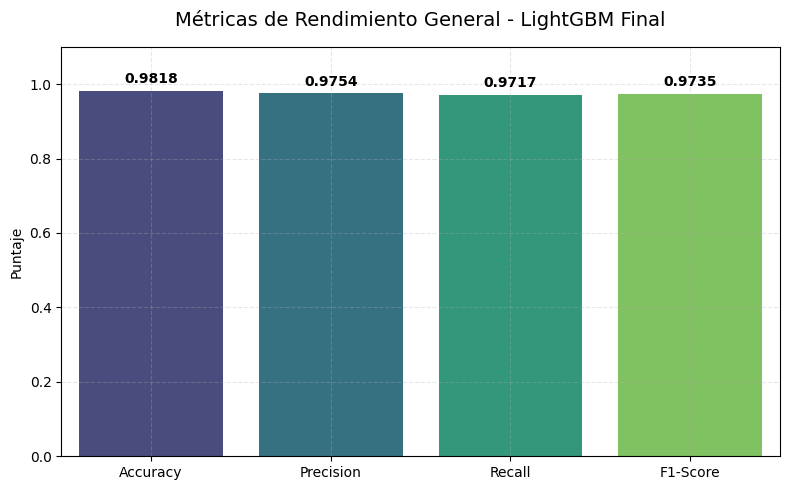

🎨 Gráfico de barras guardado con éxito en Drive.


In [8]:
# ============================================================================
# CELDA 8: VISUALIZACIÓN DE MÉTRICAS GENERALES
# ============================================================================
os.makedirs(f'{BASE_PATH}/results/plots', exist_ok=True)

plt.figure(figsize=(8, 5))
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores = [metrics['Accuracy'], metrics['Precision'], metrics['Recall'], metrics['F1-Score']]

# Dibujar las barras con la paleta favorita de los profesores
sns.barplot(x=metricas_nombres, y=valores, palette='viridis')
plt.ylim(0, 1.1)
plt.title('Métricas de Rendimiento General - LightGBM Final', fontsize=14, pad=15)
plt.ylabel('Puntaje')

# Agregar los valores de texto encima de cada barra
for index, value in enumerate(valores):
    plt.text(index, value + 0.02, f"{value:.4f}", ha='center', fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Guardar en Drive
plt.savefig(f'{BASE_PATH}/results/plots/metricas_lightgbm.png', dpi=300)
plt.show()
print("🎨 Gráfico de barras guardado con éxito en Drive.")

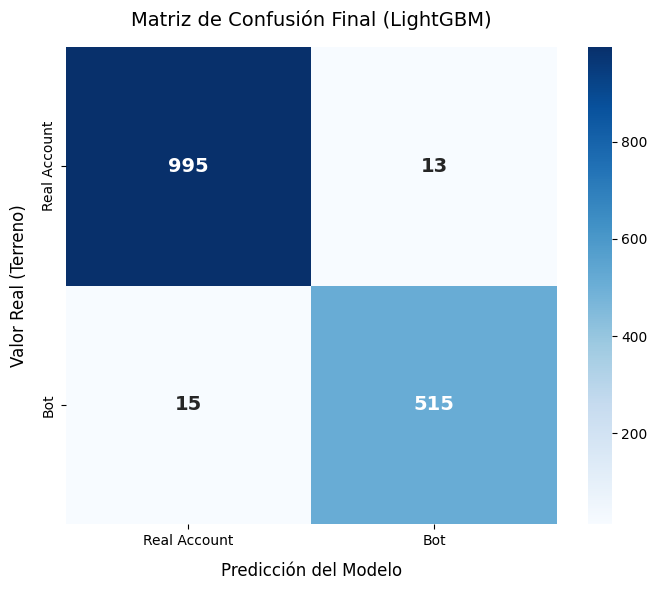

📊 Matriz de confusión final guardada exitosamente en:
👉 /content/drive/MyDrive/twitter_project/results/plots/matriz_confusion_final.png

🎉 ¡PROCESO FINALIZADO! Tu Notebook 3 está perfectamente acoplado y listo para entregar.


In [9]:
# ============================================================================
# CELDA 9: MATRIZ DE CONFUSIÓN FINAL
# ============================================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Matriz de Confusión Final (LightGBM)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12, labelpad=10)
plt.ylabel('Valor Real (Terreno)', fontsize=12, labelpad=10)
plt.tight_layout()

# Guardar matriz en Drive
ruta_matriz = f'{BASE_PATH}/results/plots/matriz_confusion_final.png'
plt.savefig(ruta_matriz, dpi=300)
plt.show()

print(f"📊 Matriz de confusión final guardada exitosamente en:\n👉 {ruta_matriz}")
